In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

In [2]:


filename = 'A:\\ASPA\\Data\\OptD\\20220217_D01_P1.mp4'
cap = cv2.VideoCapture(filename)


In [4]:


fps = int(cap.get(cv2.CAP_PROP_FPS))
vdo_width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
vdo_height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
num_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
print(fps, vdo_width, vdo_height, num_frames)

60 480 540 52660


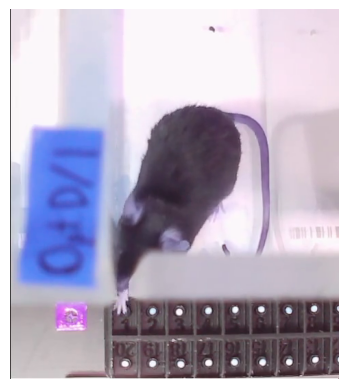

In [13]:

# Check if the frame index is within the valid range
frame_index = 963
if frame_index >= num_frames:
    print(f"Error: Frame index {frame_index} is out of bounds. Total frames: {num_frames}")
else:
    # Get the 963rd frame
    cap.set(cv2.CAP_PROP_POS_FRAMES, frame_index)
    ret, frame = cap.read()

    # Check if the frame is read successfully
    if not ret:
        print(f"Error: Could not read frame at index {frame_index}")
    else:
        # Convert the image from BGR to RGB
        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        
        # Display the image using matplotlib
        plt.imshow(frame)
        plt.axis('off')  # Hide the axis
        plt.show()

        # Save the image
        cv2.imwrite('frame_963.jpg', frame_rgb)

In [6]:
ref_x = 88
ref_y = 448
xmin = int(ref_x+30)
xmax = int(ref_x+120)
ymin = int(ref_y-20)
ymax = int(ref_y+60)


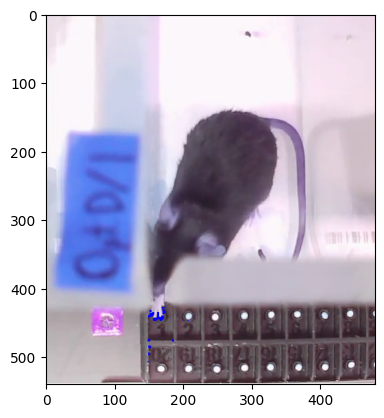

In [24]:
# Corner detection using Harris corner detection
framee = frame.copy()
gray = cv2.cvtColor(framee, cv2.COLOR_BGR2GRAY)
gray = np.float32(gray)
dst = cv2.cornerHarris(gray, 2, 3, 0.04)
dst = cv2.dilate(dst, None)
#framee[dst > 0.01 * dst.max()] = [0, 0, 255]
# Mark only the corners that are within the region of interest
framee[ymin:ymax, xmin:xmax][dst[ymin:ymax, xmin:xmax] > 0.01 * dst.max()] = [0, 0, 255]

plt.imshow(framee)

In [11]:
def detect_bottom_corners(frame, xmin, xmax, ymin, ymax):
    # Convert to grayscale
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    
    # Apply Gaussian blur to reduce noise
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)
    
    # Apply adaptive thresholding
    thresh = cv2.adaptiveThreshold(blurred, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, 
                                   cv2.THRESH_BINARY, 11, 2)
    
    # Edge detection
    edges = cv2.Canny(thresh, 50, 150)
    
    # Find contours
    contours, _ = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    # Filter contours based on area and aspect ratio
    min_area = 1000  # Adjust based on your box size
    max_area = 100000  # Adjust based on your box size
    aspect_ratio_range = (0.5, 2.0)  # Adjust based on your box shape
    
    box_contours = []
    for contour in contours:
        area = cv2.contourArea(contour)
        if min_area < area < max_area:
            x, y, w, h = cv2.boundingRect(contour)
            aspect_ratio = w / h
            if aspect_ratio_range[0] < aspect_ratio < aspect_ratio_range[1]:
                box_contours.append(contour)
    
    # Sort contours by area (largest first) and take the top 3
    box_contours = sorted(box_contours, key=cv2.contourArea, reverse=True)[:3]
    
    corners = []
    for contour in box_contours:
        # Approximate the contour to a polygon
        epsilon = 0.02 * cv2.arcLength(contour, True)
        approx = cv2.approxPolyDP(contour, epsilon, True)
        
        # If we have a quadrilateral, add its corners
        if len(approx) == 4:
            corners.extend(approx)
    
    # Filter corners based on ROI
    filtered_corners = [corner for corner in corners 
                        if xmin <= corner[0][0] <= xmax and ymin <= corner[0][1] <= ymax]
    
    # Sort corners by y-coordinate (descending) to focus on bottom corners
    filtered_corners.sort(key=lambda c: c[0][1], reverse=True)
    
    # Get the two bottom corners
    bottom_corners = filtered_corners[:2] if len(filtered_corners) >= 2 else []
    
    # Draw circles around the detected corners
    result_frame = frame.copy()
    for corner in bottom_corners:
        x, y = corner[0]
        cv2.circle(result_frame, (x, y), 5, (0, 0, 255), -1)
    
    return result_frame, bottom_corners

In [14]:
def detect_bottom_corners(frame, xmin, xmax, ymin, ymax):
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    corners = cv2.goodFeaturesToTrack(gray, maxCorners=100, qualityLevel=0.01, minDistance=10)
    corners = np.int0(corners)

    # Filter corners based on ROI
    filtered_corners = [corner for corner in corners if xmin <= corner[0][0] <= xmax and ymin <= corner[0][1] <= ymax]
    print(f"Number of corners detected within the ROI: {len(filtered_corners)}")
    # Sort corners by y-coordinate (descending) to focus on bottom corners
    filtered_corners.sort(key=lambda c: c[0][1], reverse=True)
    # # Draw circles around the filtered corners
    # frame_with_corners = frame.copy()
    # for corner in filtered_corners:
    #     x, y = corner.ravel()
    #     cv2.circle(frame_with_corners, (x, y), 5, (0, 0, 255), -1)

    # # Display the image using matplotlib
    # plt.figure(figsize=(12, 8))
    # plt.imshow(cv2.cvtColor(frame_with_corners, cv2.COLOR_BGR2RGB))

    # Parameters for filtering
    y_tolerance = 1  # Maximum y-difference for corners to be considered on the same line
    min_x_distance = 20  # Minimum x-distance between corners

    bottom_corners = []
    for i, corner1 in enumerate(filtered_corners):
        x1, y1 = corner1[0]
        for corner2 in filtered_corners[i+1:]:
            x2, y2 = corner2[0]
            
            # Check if corners have similar y-coordinates
            if abs(y1 - y2) <= y_tolerance:
                # Check if corners are far enough apart in x-direction
                if abs(x1 - x2) >= min_x_distance:
                    bottom_corners.extend([corner1, corner2])
                    break
        if len(bottom_corners) == 2:
            break

    # Draw circles around the detected corners
    result_frame = frame.copy()
    for corner in bottom_corners:
        x, y = corner.ravel()
        cv2.circle(result_frame, (x, y), 5, (0, 0, 255), -1)

    return result_frame, bottom_corners


Number of corners detected within the ROI: 12


C:\Users\3449mathews\AppData\Local\Temp\ipykernel_3656\3981541795.py:4: DeprecationWarning: `np.int0` is a deprecated alias for `np.intp`.  (Deprecated NumPy 1.24)
  corners = np.int0(corners)


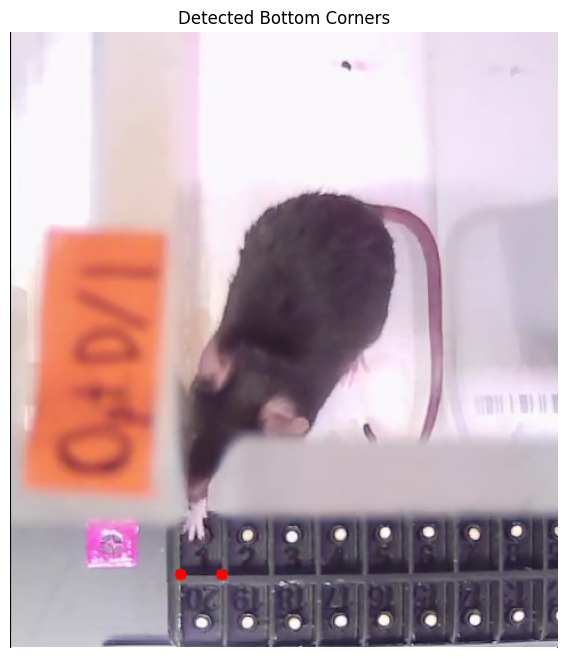

Number of detected bottom corners: 2
Coordinates of detected corners:
(149, 475)
(185, 475)


In [15]:

# Assume 'frame' is your input image and xmin, xmax, ymin, ymax define your region of interest
result_frame, corners = detect_bottom_corners(frame, xmin, xmax, ymin, ymax)

# Display the result using matplotlib
plt.figure(figsize=(12, 8))
plt.imshow(cv2.cvtColor(result_frame, cv2.COLOR_BGR2RGB))
plt.axis('off')  # Hide the axis
plt.title("Detected Bottom Corners")
plt.show()

print(f"Number of detected bottom corners: {len(corners)}")
if corners:
    print("Coordinates of detected corners:")
    for corner in corners:
        print(f"({corner[0][0]}, {corner[0][1]})")

In [63]:
# Check if the detected bottom corners are similar for frames between 963 and 983
for i in range(963, 984):
    cap.set(cv2.CAP_PROP_POS_FRAMES, i)
    ret, frame = cap.read()
    if not ret:
        print(f"Error: Could not read frame at index {i}")
        break
    result_frame, corners = detect_bottom_corners(frame, xmin, xmax, ymin, ymax)
    print(f"Frame {i}: Number of detected bottom corners: {len(corners)}")
    if corners:
        print("Coordinates of detected corners:")
        for corner in corners:
            print(f"({corner[0][0]}, {corner[0][1]})")

C:\Users\3449mathews\AppData\Local\Temp\ipykernel_9828\2665193681.py:4: DeprecationWarning: `np.int0` is a deprecated alias for `np.intp`.  (Deprecated NumPy 1.24)
  corners = np.int0(corners)


Number of corners detected within the ROI: 12
Frame 963: Number of detected bottom corners: 2
Coordinates of detected corners:
(149, 475)
(185, 475)
Number of corners detected within the ROI: 11
Frame 964: Number of detected bottom corners: 2
Coordinates of detected corners:
(149, 475)
(185, 475)
Number of corners detected within the ROI: 11
Frame 965: Number of detected bottom corners: 2
Coordinates of detected corners:
(149, 475)
(185, 475)
Number of corners detected within the ROI: 11
Frame 966: Number of detected bottom corners: 2
Coordinates of detected corners:
(149, 475)
(185, 475)
Number of corners detected within the ROI: 11
Frame 967: Number of detected bottom corners: 2
Coordinates of detected corners:
(149, 475)
(185, 475)
Number of corners detected within the ROI: 11
Frame 968: Number of detected bottom corners: 2
Coordinates of detected corners:
(149, 475)
(185, 475)
Number of corners detected within the ROI: 11
Frame 969: Number of detected bottom corners: 2
Coordinates 

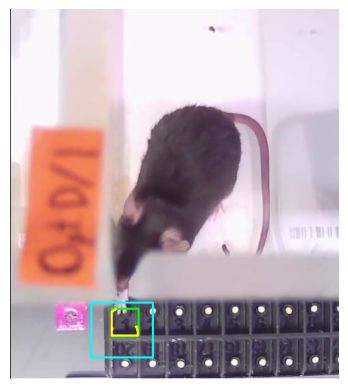

In [20]:
framee = frame.copy()
# Convert the image to grayscale
gray = cv2.cvtColor(framee, cv2.COLOR_BGR2GRAY)

# Apply Gaussian blur to reduce noise
blurred = cv2.GaussianBlur(gray, (5, 5), 0)

# Use Canny edge detection
edges = cv2.Canny(blurred, 50, 150)

# Find contours in the edge-detected image
contours, _ = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Bounds to look for contours
xmin = int(ref_x+30)
xmax = int(ref_x+120)
ymin = int(ref_y-20)
ymax = int(ref_y+60)

# Draw the bounding box
cv2.rectangle(framee, (xmin, ymin), (xmax, ymax), (255, 255, 0), 2)

# Filter contours based on size and shape
for contour in contours:
    # Get the bounding box for each contour
    x, y, w, h = cv2.boundingRect(contour)
    if (xmin < x < xmax and 
        xmin < x + w < xmax and
        ymin < y < ymax and 
        ymin < y + h < ymax and
        10 < w < 100 and 
        10 < h < 100):
        # Draw bounding box around the detected box
        cv2.rectangle(framee, (x, y), (x + w, y + h), (0, 255, 0), 2)
        # Draw the contour
        cv2.drawContours(framee, [contour], -1, (0, 255, 255), 2)

# Convert the image from BGR to RGB
frame_rgb = cv2.cvtColor(framee, cv2.COLOR_BGR2RGB)

# Display the result using matplotlib
plt.imshow(frame_rgb)
plt.axis('off')  # Hide the axis
plt.show()